#  Task 4: Named Entity Recognition (NER) from News Articles

**Goal:** Identify named entities _ People, Locations, Organizations _ from article text  
**Dataset:** CoNLL-2003 (local files: `train.txt`, `valid.txt`, `test.txt`)  
**Topics:** Sequence Labeling | NER | spaCy  

---
### Pipeline
```
Load CoNLL-2003 -> Parse BIO Tags -> Rule-based NER (spaCy sm) -> Model-based NER (spaCy lg) -> Evaluate -> Visualize
```

## Step 1: Install & Import Libraries

In [1]:
!pip install spacy pandas matplotlib seaborn --quiet

# Download both spaCy models (small + large) for comparison
!python -m spacy download en_core_web_sm --quiet
!python -m spacy download en_core_web_lg --quiet

[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict

import spacy
from spacy import displacy
from IPython.display import display, HTML

plt.style.use('seaborn-v0_8-whitegrid')
print(' Libraries ready!')

 Libraries ready!


---
## Step 2: Load & Parse the CoNLL-2003 Dataset

CoNLL-2003 format: each line is `word POS chunk NER_tag`, sentences separated by blank lines.  
NER tags use **BIO** scheme: `B-` = beginning, `I-` = inside, `O` = outside.

In [4]:
def parse_conll(filepath):
    """
    Parse a CoNLL-2003 file into a list of sentences.
    Each sentence is a list of (word, ner_tag) tuples.
    """
    sentences = []
    current   = []

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            # Skip document start markers
            if line.startswith('-DOCSTART-') or line == '':
                if current:
                    sentences.append(current)
                    current = []
                continue

            parts = line.split()
            word    = parts[0]
            ner_tag = parts[-1]   # last column is the NER tag
            current.append((word, ner_tag))

    if current:
        sentences.append(current)

    return sentences


# Load all three splits
train_sents = parse_conll('train.txt')
valid_sents = parse_conll('valid.txt')
test_sents  = parse_conll('test.txt')

print(f'Train sentences : {len(train_sents):,}')
print(f'Valid sentences : {len(valid_sents):,}')
print(f'Test sentences  : {len(test_sents):,}')
print(f'\nExample sentence:')
print(train_sents[1])

Train sentences : 14,041
Valid sentences : 3,250
Test sentences  : 3,453

Example sentence:
[('Peter', 'B-PER'), ('Blackburn', 'I-PER')]


---
## Step 3: Explore the Dataset — Tag Distribution

In [5]:
# Count all NER tags in training set
all_tags = [tag for sent in train_sents for _, tag in sent]
tag_counts = Counter(all_tags)

# Separate entity tags from 'O'
entity_tags = {k: v for k, v in tag_counts.items() if k != 'O'}

print('=== Tag Distribution (Train) ===')
for tag, count in sorted(tag_counts.items(), key=lambda x: -x[1]):
    print(f'  {tag:<12} {count:>7,}')

print(f'\nTotal tokens : {len(all_tags):,}')
print(f'Entity tokens: {sum(entity_tags.values()):,}')

=== Tag Distribution (Train) ===
  O            169,578
  B-LOC          7,140
  B-PER          6,600
  B-ORG          6,321
  I-PER          4,528
  I-ORG          3,704
  B-MISC         3,438
  I-LOC          1,157
  I-MISC         1,155

Total tokens : 203,621
Entity tokens: 34,043


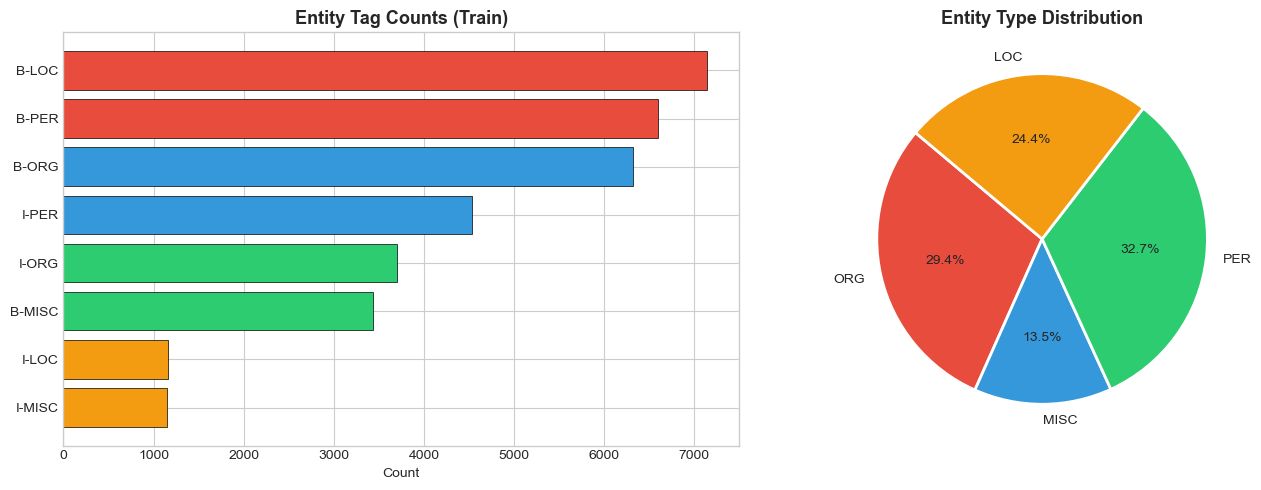

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Entity tag bar chart (excluding 'O')
sorted_entities = sorted(entity_tags.items(), key=lambda x: -x[1])
tags, counts = zip(*sorted_entities)

colors = ['#e74c3c', '#e74c3c',   # B-PER, I-PER
          '#3498db', '#3498db',   # B-ORG, I-ORG
          '#2ecc71', '#2ecc71',   # B-LOC, I-LOC
          '#f39c12', '#f39c12']   # B-MISC, I-MISC
colors = colors[:len(tags)]

axes[0].barh(list(reversed(tags)), list(reversed(counts)),
             color=list(reversed(colors)), edgecolor='black', linewidth=0.5)
axes[0].set_title('Entity Tag Counts (Train)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')

# Entity type pie chart (grouping B- and I- together)
entity_types = defaultdict(int)
for tag, count in entity_tags.items():
    etype = tag.split('-')[-1]   # PER, ORG, LOC, MISC
    entity_types[etype] += count

axes[1].pie(entity_types.values(), labels=entity_types.keys(),
            autopct='%1.1f%%', colors=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'],
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Entity Type Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('tag_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 4: Extract Ground Truth Entities from CoNLL

Convert BIO-tagged sentences into clean `(entity_text, entity_type)` pairs.

In [7]:
def extract_entities(sentences):
    """
    Convert BIO-tagged sentences → list of (entity_text, entity_type).
    Also returns plain sentence strings for feeding into spaCy.
    """
    all_entities = []
    plain_texts  = []

    for sent in sentences:
        words = [w for w, _ in sent]
        tags  = [t for _, t in sent]
        plain_texts.append(' '.join(words))

        entity_words = []
        entity_type  = None

        for word, tag in zip(words, tags):
            if tag.startswith('B-'):
                if entity_words:   # save previous entity
                    all_entities.append((' '.join(entity_words), entity_type))
                entity_words = [word]
                entity_type  = tag[2:]   # strip 'B-'
            elif tag.startswith('I-') and entity_words:
                entity_words.append(word)
            else:
                if entity_words:
                    all_entities.append((' '.join(entity_words), entity_type))
                entity_words = []
                entity_type  = None

        if entity_words:
            all_entities.append((' '.join(entity_words), entity_type))

    return all_entities, plain_texts


train_entities, train_texts = extract_entities(train_sents)
test_entities,  test_texts  = extract_entities(test_sents)

print(f'Train entities extracted: {len(train_entities):,}')
print(f'Test  entities extracted: {len(test_entities):,}')
print(f'\nSample entities:')
for ent, typ in train_entities[:10]:
    print(f'  [{typ}]  {ent}')

Train entities extracted: 23,499
Test  entities extracted: 5,648

Sample entities:
  [ORG]  EU
  [MISC]  German
  [MISC]  British
  [PER]  Peter Blackburn
  [LOC]  BRUSSELS
  [ORG]  European Commission
  [MISC]  German
  [MISC]  British
  [LOC]  Germany
  [ORG]  European Union


---
## Step 5: Rule-Based NER — spaCy Small Model (`en_core_web_sm`)

spaCy's small model uses **statistical rules + lookup tables** — fast and lightweight.

In [8]:
# Load small spaCy model
nlp_sm = spacy.load('en_core_web_sm')

print(f'Model : en_core_web_sm')
print(f'NER entity types: {nlp_sm.get_pipe("ner").labels}')

Model : en_core_web_sm
NER entity types: ('CARDINAL', 'DATE', 'EVENT', 'FAC', 'GPE', 'LANGUAGE', 'LAW', 'LOC', 'MONEY', 'NORP', 'ORDINAL', 'ORG', 'PERCENT', 'PERSON', 'PRODUCT', 'QUANTITY', 'TIME', 'WORK_OF_ART')


In [9]:
# Run NER on a sample of test sentences
SAMPLE_SIZE = 500   # use subset for speed
sample_texts = test_texts[:SAMPLE_SIZE]

# Map CoNLL types → spaCy types for fair comparison
CONLL_TO_SPACY = {'PER': 'PERSON', 'ORG': 'ORG', 'LOC': 'GPE', 'MISC': 'MISC'}

def run_spacy_ner(texts, nlp):
    """Run spaCy NER on a list of texts. Returns list of (entity_text, label) per sentence."""
    results = []
    for doc in nlp.pipe(texts, batch_size=64, disable=['tok2vec', 'tagger', 'parser', 'lemmatizer']):
        entities = [(ent.text, ent.label_) for ent in doc.ents]
        results.append(entities)
    return results


print('Running en_core_web_sm on test sample...')
sm_predictions = run_spacy_ner(sample_texts, nlp_sm)
print(f'✅ Done! Processed {len(sm_predictions)} sentences.')

# Show a few examples
print('\nSample predictions (sm):')
for i in range(3):
    print(f'  Sentence : {sample_texts[i]}')
    print(f'  Entities : {sm_predictions[i]}')
    print()

Running en_core_web_sm on test sample...
✅ Done! Processed 500 sentences.

Sample predictions (sm):
  Sentence : SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .
  Entities : [('DEFEAT', 'ORG')]

  Sentence : Nadim Ladki
  Entities : [('Nadim Ladki', 'PERSON')]

  Sentence : AL-AIN , United Arab Emirates 1996-12-06
  Entities : [('AL-AIN', 'ORG'), ('United Arab Emirates', 'GPE'), ('1996-12-06', 'DATE')]



---
## Step 6: Model-Based NER — spaCy Large Model (`en_core_web_lg`)

The large model uses **300-dimensional GloVe word vectors** for much richer context.

In [11]:
# Load large spaCy model
nlp_lg = spacy.load('en_core_web_lg')

print('Running en_core_web_lg on test sample...')
lg_predictions = run_spacy_ner(sample_texts, nlp_lg)
print(f' Done! Processed {len(lg_predictions)} sentences.')

# Show same examples
print('\nSample predictions (lg):')
for i in range(3):
    print(f'  Sentence : {sample_texts[i]}')
    print(f'  Entities : {lg_predictions[i]}')
    print()

Running en_core_web_lg on test sample...
 Done! Processed 500 sentences.

Sample predictions (lg):
  Sentence : SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .
  Entities : [('SOCCER - JAPAN', 'ORG'), ('CHINA', 'GPE')]

  Sentence : Nadim Ladki
  Entities : [('Nadim Ladki', 'PERSON')]

  Sentence : AL-AIN , United Arab Emirates 1996-12-06
  Entities : [('AL-AIN', 'PERSON'), ('United Arab Emirates', 'GPE')]



---
## Step 7: Compare Both Models — Entity Type Counts

In [12]:
def count_entity_types(predictions):
    """Count how many entities of each type were found."""
    counter = Counter()
    for sent_ents in predictions:
        for _, label in sent_ents:
            counter[label] += 1
    return counter


sm_counts = count_entity_types(sm_predictions)
lg_counts = count_entity_types(lg_predictions)

# Build comparison table
all_labels = sorted(set(list(sm_counts.keys()) + list(lg_counts.keys())))
compare_df = pd.DataFrame({
    'Entity Type' : all_labels,
    'sm (small)'  : [sm_counts.get(l, 0) for l in all_labels],
    'lg (large)'  : [lg_counts.get(l, 0) for l in all_labels]
})
print('=== Entity Count Comparison (sm vs lg) ===')
print(compare_df.to_string(index=False))

=== Entity Count Comparison (sm vs lg) ===
Entity Type  sm (small)  lg (large)
   CARDINAL         321         359
       DATE         216         119
      EVENT          19          22
        FAC           3           3
        GPE         267         337
   LANGUAGE           1           0
        LAW           3           3
        LOC           3           5
      MONEY           8           7
       NORP          33          45
    ORDINAL          33          34
        ORG         154         140
    PERCENT           3           2
     PERSON         317         350
    PRODUCT           9           6
   QUANTITY          10          18
       TIME          16          25
WORK_OF_ART           1           0


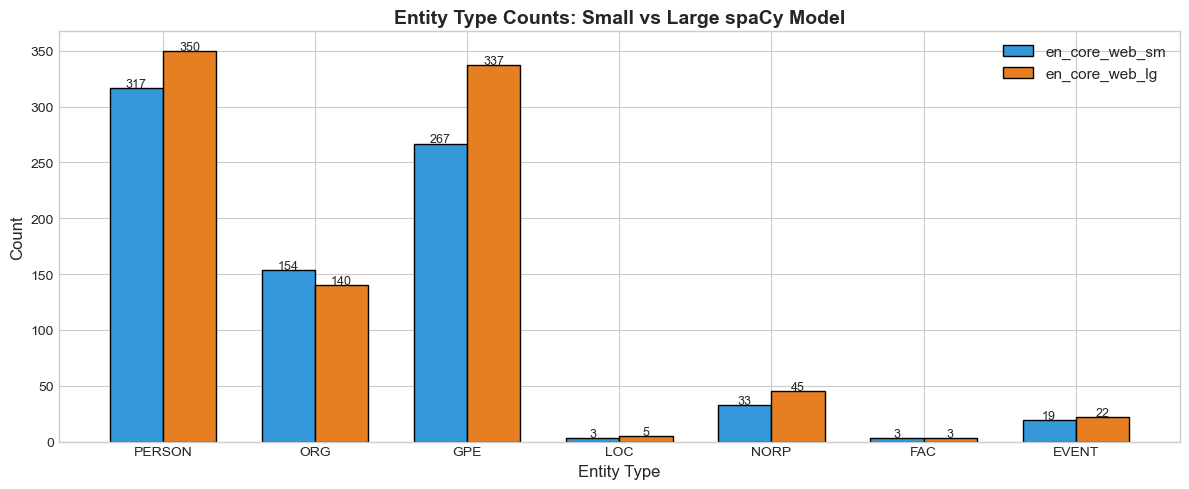

In [13]:
# Focus on main 4 types: PERSON, ORG, GPE, LOC
main_types = ['PERSON', 'ORG', 'GPE', 'LOC', 'NORP', 'FAC', 'EVENT']
main_types = [t for t in main_types if t in all_labels]

sm_vals = [sm_counts.get(t, 0) for t in main_types]
lg_vals = [lg_counts.get(t, 0) for t in main_types]

x = np.arange(len(main_types))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, sm_vals, width, label='en_core_web_sm', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, lg_vals, width, label='en_core_web_lg', color='#e67e22', edgecolor='black')

ax.set_title('Entity Type Counts: Small vs Large spaCy Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Entity Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(main_types)
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(bar.get_height()), ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(bar.get_height()), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8: Most Common Entities per Type

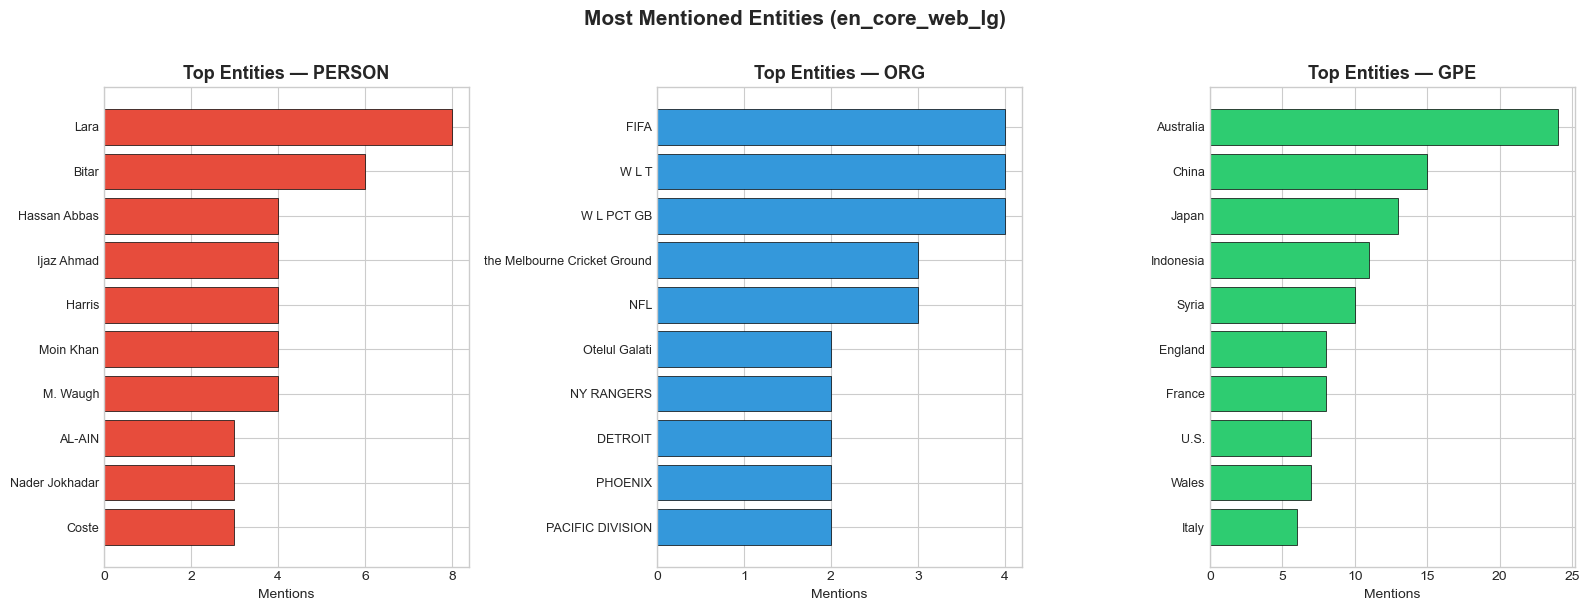

In [14]:
def top_entities_by_type(predictions, target_types, top_n=10):
    """Return top N most common entities for each target type."""
    buckets = defaultdict(Counter)
    for sent_ents in predictions:
        for text, label in sent_ents:
            if label in target_types:
                buckets[label][text.strip()] += 1
    return {label: buckets[label].most_common(top_n) for label in target_types if label in buckets}


target_types = ['PERSON', 'ORG', 'GPE']
top_lg = top_entities_by_type(lg_predictions, target_types)

fig, axes = plt.subplots(1, len(top_lg), figsize=(16, 6))
type_colors = {'PERSON': '#e74c3c', 'ORG': '#3498db', 'GPE': '#2ecc71'}

for ax, (etype, items) in zip(axes, top_lg.items()):
    if not items:
        continue
    names, counts = zip(*items)
    ax.barh(list(reversed(names)), list(reversed(counts)),
            color=type_colors.get(etype, '#95a5a6'), edgecolor='black', linewidth=0.5)
    ax.set_title(f'Top Entities — {etype}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mentions')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Most Mentioned Entities (en_core_web_lg)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('top_entities.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9 (BONUS): Visualize Entities with displaCy

In [15]:
# Pick a few rich sentences from the test set to visualize
demo_sentences = [
    "Peter Blackburn reported that the European Commission met in Brussels on Thursday.",
    "Germany's Angela Merkel and France's Emmanuel Macron held talks at the United Nations.",
    "Apple CEO Tim Cook announced a new partnership with Microsoft in New York City."
]

print(' displaCy Entity Visualization (en_core_web_lg) \n')

for sent in demo_sentences:
    doc = nlp_lg(sent)
    html = displacy.render(doc, style='ent', page=False, jupyter=False)
    display(HTML(f'<div style="margin-bottom:20px; font-size:14px">{html}</div>'))

 displaCy Entity Visualization (en_core_web_lg) 



In [17]:
# Also show side-by-side comparison sm vs lg on the same sentence
test_sent = "The United States president met with European Union leaders in Paris last Friday."

doc_sm = nlp_sm(test_sent)
doc_lg = nlp_lg(test_sent)

print(f'Sentence: "{test_sent}"\n')
print('--- en_core_web_sm ---')
for ent in doc_sm.ents:
    print(f'  [{ent.label_}]  {ent.text}')

print('\n--- en_core_web_lg ---')
for ent in doc_lg.ents:
    print(f'  [{ent.label_}]  {ent.text}')

print('\n displaCy: sm model ')
display(HTML(displacy.render(doc_sm, style='ent', page=False, jupyter=False)))

print('\n displaCy: lg model ')
display(HTML(displacy.render(doc_lg, style='ent', page=False, jupyter=False)))

Sentence: "The United States president met with European Union leaders in Paris last Friday."

--- en_core_web_sm ---
  [GPE]  The United States
  [ORG]  European Union
  [GPE]  Paris
  [DATE]  last Friday

--- en_core_web_lg ---
  [GPE]  United States
  [ORG]  European Union
  [GPE]  Paris
  [DATE]  last Friday

 displaCy: sm model 



 displaCy: lg model 


---
## Step 10: Export Entities to DataFrame

In [18]:
# Build a clean DataFrame of all extracted entities
rows = []
for sent_text, sent_ents in zip(sample_texts[:100], lg_predictions[:100]):
    for ent_text, ent_label in sent_ents:
        rows.append({
            'sentence' : sent_text[:80] + '...' if len(sent_text) > 80 else sent_text,
            'entity'   : ent_text,
            'type'     : ent_label
        })

entities_df = pd.DataFrame(rows)
print(f'Total entities captured: {len(entities_df)}')
entities_df.head(15)

Total entities captured: 337


,sentence,entity,type
0,"SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRI...",SOCCER - JAPAN,ORG
1,"SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRI...",CHINA,GPE
2,Nadim Ladki,Nadim Ladki,PERSON
3,"AL-AIN , United Arab Emirates 1996-12-06",AL-AIN,PERSON
4,"AL-AIN , United Arab Emirates 1996-12-06",United Arab Emirates,GPE
5,Japan began the defence of their Asian Cup tit...,Japan,GPE
6,Japan began the defence of their Asian Cup tit...,Asian Cup,EVENT
7,Japan began the defence of their Asian Cup tit...,2-1,CARDINAL
8,Japan began the defence of their Asian Cup tit...,Syria,GPE
9,Japan began the defence of their Asian Cup tit...,Group C,ORG


---
## Step 11: Summary

In [20]:
total_sm = sum(sm_counts.values())
total_lg = sum(lg_counts.values())

print('=' * 55)
print('       NER FROM NEWS ARTICLES — SUMMARY')
print('=' * 55)
print(f'Dataset         : CoNLL-2003')
print(f'Train sentences : {len(train_sents):,}')
print(f'Test sentences  : {len(test_sents):,}')
print(f'Sample used     : {SAMPLE_SIZE} test sentences')
print()
print('--- Model Comparison ---')
print(f'  en_core_web_sm  ->  {total_sm:,} entities found')
print(f'  en_core_web_lg  ->  {total_lg:,} entities found')
print()
print('--- Top Entity Types (lg model) ---')
for label, count in lg_counts.most_common(6):
    print(f'  {label:<12}  {count:>5,}')
print('=' * 55)

       NER FROM NEWS ARTICLES — SUMMARY
Dataset         : CoNLL-2003
Train sentences : 14,041
Test sentences  : 3,453
Sample used     : 500 test sentences

--- Model Comparison ---
  en_core_web_sm  ->  1,417 entities found
  en_core_web_lg  ->  1,475 entities found

--- Top Entity Types (lg model) ---
  CARDINAL        359
  PERSON          350
  GPE             337
  ORG             140
  DATE            119
  NORP             45
